In [1]:
!pip install yfinance

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1

# Import Libraries

In [3]:

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Download Stock Data

In [4]:
ticker = "AAPL"

df = yf.download(ticker, start="2018-01-01", end="2024-01-01")

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2018-01-02,40.304176,40.313537,39.602258,39.812835,102223600
2018-01-03,40.297157,40.839976,40.233987,40.367350,118071600
2018-01-04,40.484337,40.587286,40.262063,40.369689,89738400
2018-01-05,40.945259,41.031828,40.489013,40.580262,94640000
2018-01-08,40.793175,41.087979,40.694903,40.793175,82271200


# Prepare Target Variable (Next Day Close)

# Selecting Features

In [6]:
X = df[["Open","High","Low","Volume"]]

y = df["Target"]

# Train Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Train Model

In [8]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# Make Predictions

In [9]:
y_pred = model.predict(X_test)

# Model Performance


In [10]:
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.9819283577832754


# Plot Actual vs Predicted Prices


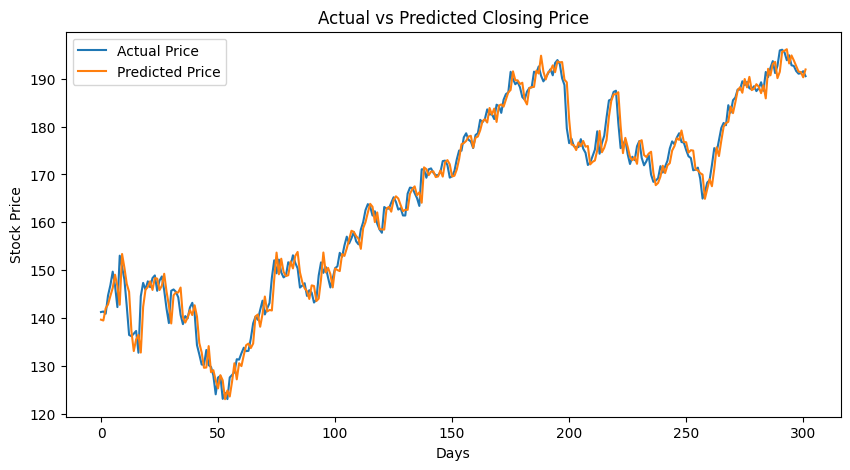

In [11]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values, label="Actual Price")
plt.plot(y_pred, label="Predicted Price")

plt.title("Actual vs Predicted Closing Price")
plt.xlabel("Days")
plt.ylabel("Stock Price")

plt.legend()

plt.show()

# Predict Tomorrow Price


In [12]:
latest_data = X.iloc[-1:]

prediction = model.predict(latest_data)

print("Predicted Next Day Close Price:", prediction[0])

Predicted Next Day Close Price: 191.9466689093112
